# Does a pre-fire image help? Uni- vs bi-temporal burnt-area segmentation on FLOGA
UTS 31005 Machine Learning — Assignment 2 (Option 2: practical ML system) · Oliver Revis, 24848259

**RQ1:** On FLOGA (Greek wildfires, Sentinel-2), does adding a pre-fire image to the post-fire image improve
burnt-area segmentation, under otherwise matched conditions (same U-Net, bands, loss, optimiser, data, seeds)?

**RQ2:** Applied zero-shot to Australian fires, does the bi-temporal advantage hold? (Not completed; see section 9.)

FLOGA's benchmark makes every deep model bi-temporal to suppress false alarms, but never removes the pre-fire image
to measure what it adds, while post-fire-only models are also common in the literature. Two U-Nets that differ only
in their first convolution are trained identically here: M1 sees the post-fire image (9 bands), M2 the stacked pre-
and post-fire images (18 bands). Hypotheses: **H1** the gain is mainly precision; **H2** it concentrates on pixels
that look burnt without being burnt by this fire (other or older burns, bare land, cropland, water).

**How this notebook was run.** Cells marked **(not run)** exist so anyone can reproduce the work from scratch; they
were run once locally. The rest was executed on an AMD Radeon RX 9060 XT (16 GB; ROCm 7.2.1, PyTorch 2.9.1) in
stages (preparation and pilot, experiment, final runs and evaluation), so execution counts restart at 6.4, 6.5 and 7.
Three cells (the 7.1 results table, the 8.2 land-cover table and the 8.4 largest-gap patches) were added afterwards
and computed from the same saved checkpoints, so they show no execution number. Run logs are in `results/logs/`.
Reusable code lives in `src/`; this notebook calls it and prints the key functions next to the maths they implement.

## 1. Setup

### 1.1 Get the code (not run)
On Colab or a fresh machine, clone the public repo and move into it.

In [ ]:
# !git clone https://github.com/Blakey4/temporal-bushfire-segmentation.git
# %cd temporal-bushfire-segmentation

### 1.2 Install requirements (not run)
PyTorch is installed separately because the right build depends on the GPU:
NVIDIA → CUDA wheel from pytorch.org; AMD on Windows → AMD's ROCm "PyTorch on Windows" wheel.

In [ ]:
# !pip install -r requirements.txt

### 1.3 Imports and configuration
Everything you might change between runs is in this one cell.

In [ ]:
import inspect
import shutil
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()  # repo root
sys.path.insert(0, str(ROOT))

from src import prepare_floga, make_splits, dataset, models, losses, train, metrics, evaluate
from src import visualisation as vis

# Paths (relative to the repository)
DATA_ROOT = ROOT.parent / "floga_dataset"  # FLOGA V2 download (1.1 TB), next to the repo folder
OUT_DIR = ROOT / "data" / "prepared"       # patches, patch_index.csv, splits.csv, band_stats.json
RUNS_DIR = ROOT / "results" / "runs"       # one folder per training run: config, log, checkpoints

# Which steps to run (False = reload the saved results instead)
RUN_PREPARE = True      # 2.1-2.2: cut the raw scenes into patches (~16 min)
RUN_PILOT = True        # 6.2: pilot run, seed 0, both models
RUN_EXPERIMENTS = True  # 6.4: refinement experiments
RUN_TRAINING = True     # 6.5: final runs, all seeds

# Experiment settings
SPLIT_SEED = 0          # one fixed fire-level split for every run
SEEDS = [0, 1, 2]       # training seeds (initialisation and batch order)
MODES = ["uni", "bi"]   # M1: post only (9 channels), M2: pre + post (18 channels)
REFINE_EPOCHS = 30      # pilot and refinement experiments
EPOCHS = 30             # final runs: pilot validation F1 levels off by ~epoch 20, no over-fitting
BATCH_SIZE = 8
LR = 1e-3
BASE = 64               # U-Net base width (channels of the first block)
AMP = True              # mixed precision (GPU only)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "")

device: cuda AMD Radeon RX 9060 XT


### 1.4 Download FLOGA V2 (not run)
~1.1 TB: 56 tar shards of whole Sentinel-2 scenes (plus MODIS, which we don't use). Run once; takes many hours.

In [ ]:
# !hf download orion-ai-lab/FLOGA-GeoTIFFs --repo-type dataset --local-dir {DATA_ROOT}

## 2. Data preparation
FLOGA V2 provides 461 Sentinel-2 rasters (one fire seen in one Sentinel-2 tile) covering 343 Greek wildfires from
2017 to 2021, each a pre/post pair with an expert label, a cloud mask, a water mask and land cover. The label is
turned into **1** = burnt by this fire, **0** = not burnt and **255** = ignore (burnt by another fire that year, cloud,
or no data), so the task stays a clean binary segmentation. Each raster is cut into 256 × 256 patches; patches that
are entirely ignore, ≥ 90% water or > 15% cloud are dropped, and every positive patch is kept with the same number of
random negatives (1:1). Format details and the reasoning behind each rule: `data/README.md` and `JOURNAL.md`.

### 2.1 Cut the raw scenes into patches (`src/prepare_floga.py`)
Reads the files in place inside the tar shards; ~15–20 min for the full dataset.

In [ ]:
if RUN_PREPARE:
    # Add fires=[784755, 878173] to try it on a few fires first
    patch_index = prepare_floga.prepare(DATA_ROOT, OUT_DIR)
else:
    patch_index = pd.read_csv(OUT_DIR / "patch_index.csv")
patch_index.head()

[1/461] 2017 499999_0: 1 positive, 1 negative patches


[2/461] 2017 499999_1: 2 positive, 2 negative patches


[3/461] 2017 501230_2: 0 positive, 0 negative patches


[4/461] 2017 501230_3: 0 positive, 0 negative patches


[5/461] 2017 501699_4: 1 positive, 1 negative patches


...

[458/461] 2021 893086_146: 2 positive, 2 negative patches


[459/461] 2021 893637_147: 0 positive, 0 negative patches


[460/461] 2021 893697_148: 1 positive, 1 negative patches


[461/461] 2021 893798_149: 0 positive, 0 negative patches
Saved 1494 patches (747 positive) from 274 fires to D:\temporal-bushfire-segmentation\data\prepared


,patch_id,year,fire_id,raster,row,col,is_positive,burnt_px,ignore_frac,cloud_frac,water_frac,other_burnt_px
0,2017_499999_0_r00256_c01792,2017,499999,499999_0,256,1792,True,903,0.028412,0.028412,0.001755,0
1,2017_499999_0_r02560_c04864,2017,499999,499999_0,2560,4864,False,0,0.000000,0.000000,0.001099,0
2,2017_499999_1_r01280_c01792,2017,499999,499999_1,1280,1792,True,337,0.043671,0.043671,0.001709,0
3,2017_499999_1_r01536_c01792,2017,499999,499999_1,1536,1792,True,567,0.681076,0.000000,0.000000,0
4,2017_499999_1_r01024_c04096,2017,499999,499999_1,1024,4096,False,0,0.000000,0.000000,0.001282,0


### 2.2 Train / validation / test split (`src/make_splits.py`)
Whole fires go to one set (no leakage between overlapping patches); split 60/20/20 within each year.

In [ ]:
if RUN_PREPARE:
    splits = make_splits.make_splits(OUT_DIR, seed=SPLIT_SEED)
else:
    splits = pd.read_csv(OUT_DIR / "splits.csv")

       fires  patches  positive
split                          
train    165     1008       504
val       55      244       122
test      54      242       121


## 3. Model inputs (`src/dataset.py`)
Raw digital numbers are converted to surface reflectance, (DN − 1000) / 10000 clipped to [0, 1], then z-scored per
band with the mean and standard deviation of the **training fires only**. Pre and post images share one set of
statistics, so the pre → post change is preserved. M1 receives the post image (9 channels), M2 the pre and post images
stacked (18 channels). Training augmentation is one of the 8 flip / 90° rotation combinations, applied identically to
image and label and seeded by (seed, epoch, patch), so both models see exactly the same augmented batches.

In [ ]:
# Per-band mean and std of reflectance over the training fires only
if RUN_PREPARE:
    stats = dataset.compute_band_stats(OUT_DIR)
else:
    stats = dataset.load_band_stats(OUT_DIR)

pd.DataFrame(stats, index=prepare_floga.BANDS_OUT).round(3)

,mean,std
B02,0.061,0.056
B03,0.085,0.060
B04,0.097,0.075
B05,0.135,0.079
B06,0.201,0.097
B07,0.228,0.111
B8A,0.249,0.118
B11,0.227,0.115
B12,0.157,0.091


In [ ]:
datasets = {
    (split, mode): dataset.FlogaPatches(OUT_DIR, split, mode, stats, augment=(split == "train"))
    for split in ["train", "val", "test"]
    for mode in MODES
}

x, y, fire_id = datasets["train", "bi"][0]
print("bi input:", tuple(x.shape), "| uni input:", tuple(datasets["train", "uni"][0][0].shape),
      "| label values:", y.unique().tolist())

bi input: (18, 256, 256) | uni input: (9, 256, 256) | label values: [0.0, 1.0, 255.0]


## 4. Data exploration
Whole fires are split 60/20/20 within each year: 165 / 55 / 54 fires and 1,008 / 244 / 242 patches, each split
half positive. About 11% of pixels are ignore (mostly cloud, other fires and no data). Burnt pixels are only 8.9% of the
valid training pixels, so accuracy would be misleading: predicting "unburnt" everywhere scores 91%.

In [ ]:
index = patch_index.merge(splits, on=["year", "fire_id"])
summary = index.groupby("split").agg(
    fires=("fire_id", "nunique"),
    patches=("patch_id", "size"),
    positive=("is_positive", "sum"),
    mean_ignore=("ignore_frac", "mean"),
)

size_gb = sum(f.stat().st_size for f in (OUT_DIR / "patches").glob("*.npz")) / 1e9
print(f"prepared data on disk: {size_gb:.1f} GB")
summary.reindex(["train", "val", "test"])

prepared data on disk: 3.8 GB


,fires,patches,positive,mean_ignore
split,,,,
train,165,1008,504,0.111223
val,55,244,122,0.116651
test,54,242,121,0.113956


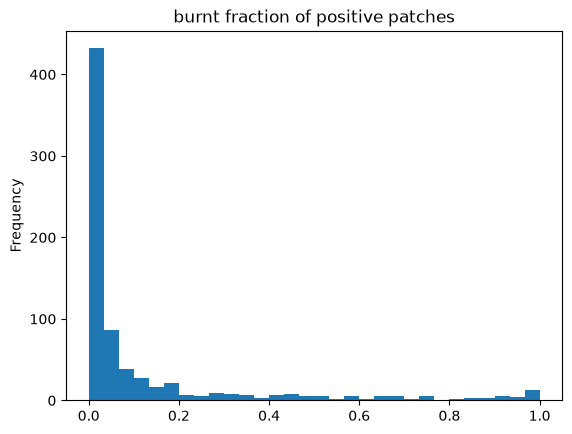

In [ ]:
# Burnt fraction of the positive patches
positives = index[index["is_positive"]]
(positives["burnt_px"] / 256**2).plot.hist(bins=30, title="burnt fraction of positive patches");

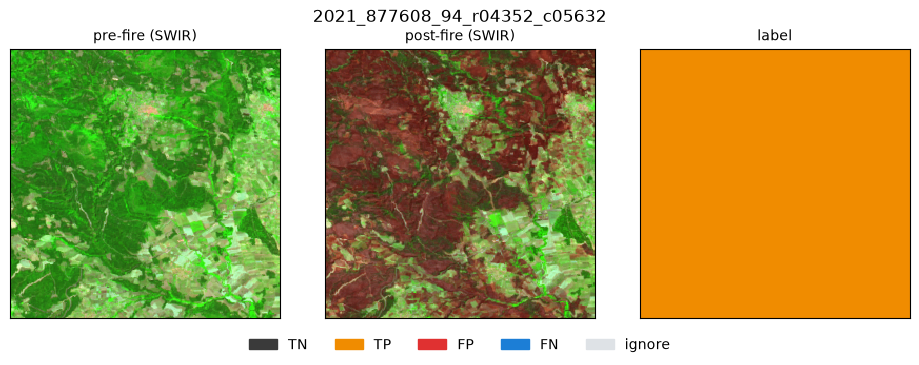

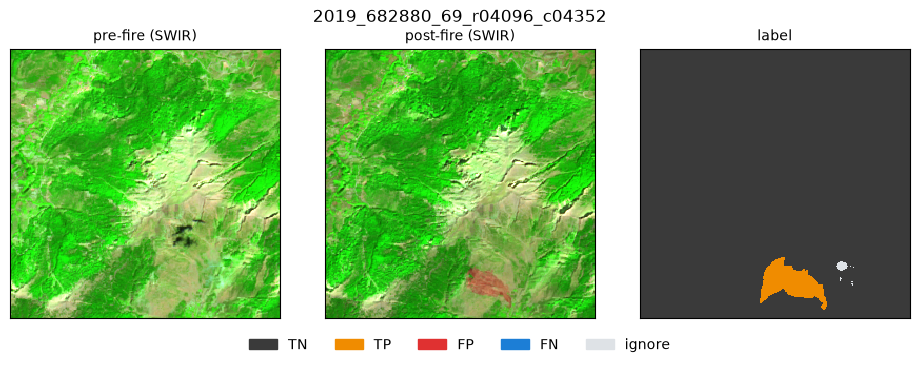

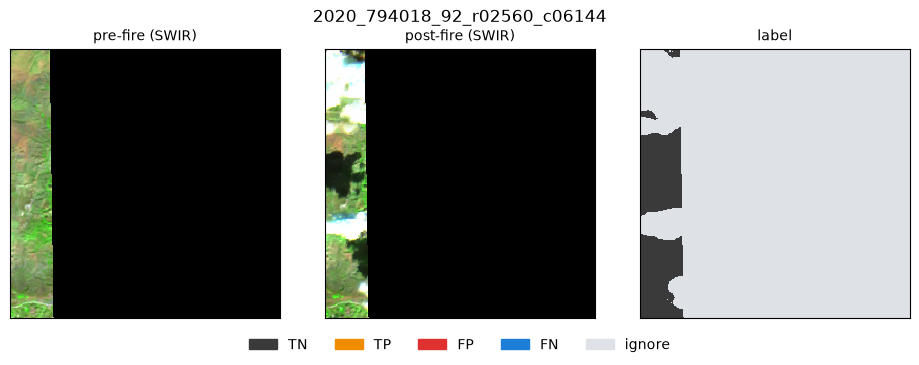

In [ ]:
# Example patches: pre / post (SWIR composite: burn = red-brown) and label (orange = burnt, grey = ignore)
by_size = positives.sort_values("burnt_px", ascending=False)["patch_id"]
examples = by_size.iloc[[0, len(by_size) // 2, -1]]  # largest, middle and smallest burn

for patch_id in examples:
    p = np.load(OUT_DIR / "patches" / f"{patch_id}.npz")
    vis.plot_patch_comparison(p["pre"], p["post"], p["label"], probs={}, title=patch_id)

## 5. Model (`src/models.py`)
A U-Net of depth 4 and base width 64: four encoder blocks (64 → 512 channels), each two 3 × 3 convolutions with
GroupNorm and ReLU followed by 2 × 2 max-pooling; a 1,024-channel bottleneck at 1/16 resolution; four decoder blocks
that upsample with a 2 × 2 transposed convolution and concatenate the matching encoder output (skip connection); and
a 1 × 1 convolution giving one logit per pixel. GroupNorm normalises per sample, so training behaves the same at batch
size 8 on any GPU. M1 and M2 differ only in the first convolution: M2's extra 5,184 weights (9 channels × 64 filters ×
3 × 3) are the whole difference. Setting them to zero reproduces M1, so M1's hypothesis space is a subset of M2's: any
gap between them comes from estimation or optimisation, not capacity.

In [ ]:
for mode in MODES:
    m = models.UNet(9 if mode == "uni" else 18, base=BASE)
    print(f"{mode}: {models.count_parameters(m):,} parameters")

print(inspect.getsource(models.conv_block))

uni: 31,041,089 parameters
bi: 31,046,273 parameters
def conv_block(in_channels, out_channels, norm="group"):
    """The plain U-Net block: (3x3 conv -> norm -> ReLU) twice. Bias is dropped as the norm has its own."""
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
        norm_layer(norm, out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
        norm_layer(norm, out_channels),
        nn.ReLU(inplace=True),
    )



## 6. Training and refinement (`src/losses.py`, `src/train.py`)
The loss is binary cross-entropy averaged over the valid pixels only (label 255 is excluded from the loss and the
metrics). Both models are trained with Adam (learning rate 1e-3, no weight decay), a cosine schedule over 30 epochs,
batch size 8 and mixed precision, and the checkpoint with the best **validation per-event F1** is kept. Both models
always get identical data, augmentations, batch order and settings.

**Refinement protocol.** Settings were refined on the **validation fires only**; the test fires were not evaluated
until section 7:
1. **Pilot** (6.2): seed 0, both models, the starting configuration.
2. **Diagnose** (6.3): training curves, precision vs recall, threshold sweep.
3. **Experiments** (6.4): each changes **one** setting from the baseline, for **both** models, seed 0.
4. **Decide** (6.4, decision record): keep a change only if it raises validation per-event F1 by more than ~0.03 for both models.
5. **Final runs** (6.5): the chosen configuration × 3 seeds × both models.

In [ ]:
print(inspect.getsource(losses.masked_bce))
print(inspect.getsource(losses.make_loss))

def masked_bce(logits, target, ignore=IGNORE, pos_weight=None):
    """Binary cross-entropy averaged over the pixels that aren't marked `ignore`.

    For a pixel with label y in {0, 1} and logit z, with p = sigmoid(z):
        loss = -[w y log p + (1 - y) log(1 - p)]
    where w = pos_weight (default 1) up-weights errors on burnt pixels.
    """
    valid = target != ignore
    if not valid.any():
        return logits.sum() * 0.0  # keeps the graph valid for an all-ignore batch
    weight = None if pos_weight is None else torch.tensor(pos_weight, device=logits.device)
    return F.binary_cross_entropy_with_logits(logits[valid], target[valid], pos_weight=weight)

def make_loss(name="bce", pos_weight=None):
    """The loss used for training: "bce", "dice" or "bce+dice" (their sum)."""
    if name == "bce":
        return lambda logits, target: masked_bce(logits, target, pos_weight=pos_weight)
    if name == "dice":
        return masked_dice
    if name == "bce+dice":
        return la

### 6.1 Baseline configuration
Every experiment changes one entry of this dictionary. All runs are saved under `RUNS_DIR/<name>/` with their
`config.json`, `log.csv` and checkpoints.

In [ ]:
BASELINE = dict(
    epochs=REFINE_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    base=BASE,
    norm="group",
    block="plain",
    loss="bce",
    pos_weight=None,
    optimizer="adam",
    weight_decay=0.0,
    schedule="cosine",
    amp=AMP,
    num_workers=0,
)


def run(name, mode, seed, config, train_now):
    """Train one run, or reload its log if train_now is False."""
    if train_now:
        print(f"=== {name} ===")
        return train.train(OUT_DIR, RUNS_DIR / name, mode=mode, seed=seed, **config)
    return pd.read_csv(RUNS_DIR / name / "log.csv")


def run_summary(logs):
    """One row per run: the best validation epoch and the numbers needed to diagnose it."""
    rows = {}
    for name, log in logs.items():
        best = log.loc[log["val_event_f1"].idxmax()]
        rows[name] = {
            "best epoch": int(best["epoch"]),
            "epochs": len(log),
            "val event F1": best["val_event_f1"],
            "val precision": best["val_event_precision"],
            "val recall": best["val_event_recall"],
            "val pooled F1": best["val_pooled_f1"],
            "final train loss": log["train_loss"].iloc[-1],
            "final val BCE": log["val_bce"].iloc[-1],
            "lowest val BCE at epoch": int(log.loc[log["val_bce"].idxmin(), "epoch"]),
            "s / epoch": log["seconds"].mean(),
        }
    return pd.DataFrame(rows).T.round(3)

### 6.2 Pilot run (seed 0, both models)
At base 64 on the RX 9060 XT an epoch took about 37 s (M1) and 44 s (M2), roughly 20 minutes per 30-epoch run.

=== pilot_uni ===


uni model: 31,041,089 parameters | 1008 train / 244 val patches | device cuda


epoch   1 | lr 1.00e-03 | train 0.1585 | val 0.0809 | event F1 0.002 (P 0.50 R 0.00) | 48s  *best*


epoch   2 | lr 9.97e-04 | train 0.0852 | val 0.0474 | event F1 0.651 (P 0.82 R 0.63) | 37s  *best*


epoch   3 | lr 9.89e-04 | train 0.0723 | val 0.0508 | event F1 0.358 (P 0.89 R 0.28) | 36s


...

epoch  26 | lr 6.70e-05 | train 0.0307 | val 0.0235 | event F1 0.792 (P 0.86 R 0.80) | 44s


epoch  27 | lr 4.32e-05 | train 0.0302 | val 0.0235 | event F1 0.784 (P 0.87 R 0.78) | 44s


epoch  28 | lr 2.45e-05 | train 0.0299 | val 0.0233 | event F1 0.791 (P 0.86 R 0.80) | 44s


epoch  29 | lr 1.09e-05 | train 0.0295 | val 0.0234 | event F1 0.789 (P 0.87 R 0.79) | 44s


epoch  30 | lr 2.74e-06 | train 0.0293 | val 0.0234 | event F1 0.789 (P 0.87 R 0.80) | 44s


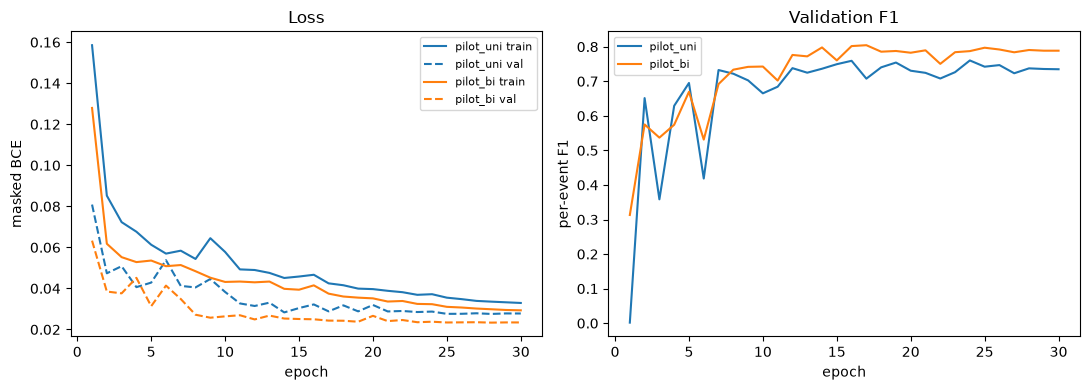

In [ ]:
pilot_logs = {f"pilot_{m}": run(f"pilot_{m}", m, 0, BASELINE, RUN_PILOT) for m in MODES}
vis.plot_training_curves(pilot_logs);

### 6.3 Diagnose the pilot (validation only)

| What you see | Means | Candidate change |
|---|---|---|
| Best val F1 in the last few epochs; train loss still falling | under-trained | more `epochs` |
| Best val F1 early, then val BCE rises while train loss keeps falling | over-fitting | fewer epochs, `base=32`, `weight_decay` |
| Train and val loss both high and flat | under-fitting | `base`, `block="residual"`, `lr` |
| Loss spikes / unstable curves | learning rate too high | lower `lr` |
| Precision much higher than recall (misses burn) | imbalance: loss dominated by unburnt pixels | `pos_weight`, `loss="bce+dice"`, lower threshold |
| Recall much higher than precision (false alarms) | over-predicts burn | check which land cover (section 8), higher threshold |
| Best threshold (below) far from 0.5 | loss vs objective mismatch | `loss="bce+dice"`, or report a tuned threshold |
| `s / epoch` high, GPU waiting | data loading bottleneck | `num_workers=4` |

In [ ]:
run_summary(pilot_logs)

,best epoch,epochs,val event F1,val precision,val recall,val pooled F1,final train loss,final val BCE,lowest val BCE at epoch,s / epoch
pilot_uni,24.0,30.0,0.760,0.820,0.790,0.832,0.033,0.028,28.0,37.033
pilot_bi,17.0,30.0,0.804,0.864,0.816,0.870,0.029,0.023,28.0,44.433


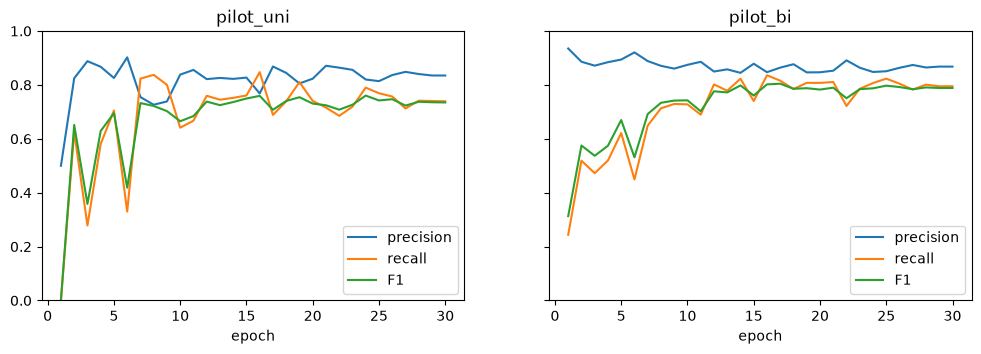

In [ ]:
# Validation precision, recall and F1 per epoch
fig, axes = plt.subplots(1, len(pilot_logs), figsize=(6 * len(pilot_logs), 3.5), sharey=True)
for ax, (name, log) in zip(np.atleast_1d(axes), pilot_logs.items()):
    for col, label in [("val_event_precision", "precision"),
                       ("val_event_recall", "recall"),
                       ("val_event_f1", "F1")]:
        ax.plot(log["epoch"], log[col], label=label)
    ax.set(title=name, xlabel="epoch", ylim=(0, 1))
    ax.legend()

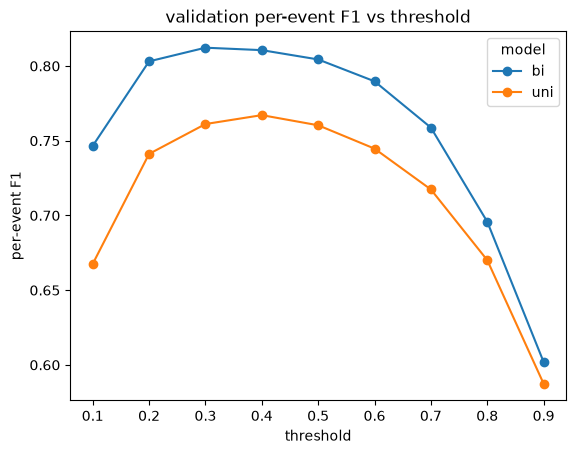

In [ ]:
# Threshold sweep on validation: does 0.5 also maximise per-event F1?
thresholds = np.round(np.arange(0.1, 0.91, 0.1), 1)
sweep = []
for m in MODES:
    model, _ = evaluate.load_model(RUNS_DIR / f"pilot_{m}" / "best.pt", DEVICE)
    for t in thresholds:
        c, _ = evaluate.predict_counts(model, datasets["val", m], DEVICE, threshold=t)
        sweep.append(metrics.summarise(c).to_frame().T.assign(model=m, threshold=t))

sweep = pd.concat(sweep)
f1_by_threshold = sweep.pivot(index="threshold", columns="model", values="event_f1")
ax = f1_by_threshold.plot(marker="o", title="validation per-event F1 vs threshold")
ax.set_ylabel("per-event F1");

**Pilot findings.** Best validation per-event F1 was 0.760 (M1, epoch 24) and 0.804 (M2, epoch 17). Neither
model over-fitted: validation BCE was lowest at epoch 28 of 30 for both, and F1 levelled off by about epoch 20, so 30
epochs were kept for the final runs. M1's F1 dipped in some early epochs before settling. The threshold sweep peaked
at 0.3–0.4, only +0.007 to +0.008 F1 above 0.5, so 0.5 was kept. Precision was higher than recall for both models,
which motivated one experiment: up-weighting burnt pixels in the loss.

### 6.4 Refinement experiments (one change each, seed 0, both models, validation only)
One experiment was run, `pos_weight = 3` (burnt pixels weighted 3× in BCE), motivated by the pilot's precision being
higher than its recall. The other candidates are listed but were not run.

=== exp_pos_weight_3_uni ===


uni model: 31,041,089 parameters | 1008 train / 244 val patches | device cuda


epoch   1 | lr 1.00e-03 | train 0.2755 | val 0.1134 | event F1 0.624 (P 0.81 R 0.61) | 42s  *best*


epoch   2 | lr 9.97e-04 | train 0.1587 | val 0.0991 | event F1 0.599 (P 0.79 R 0.58) | 36s


epoch   3 | lr 9.89e-04 | train 0.1367 | val 0.1206 | event F1 0.432 (P 0.88 R 0.36) | 36s


...

epoch  26 | lr 6.70e-05 | train 0.0527 | val 0.0415 | event F1 0.816 (P 0.82 R 0.88) | 44s


epoch  27 | lr 4.32e-05 | train 0.0513 | val 0.0412 | event F1 0.818 (P 0.82 R 0.88) | 44s


epoch  28 | lr 2.45e-05 | train 0.0504 | val 0.0407 | event F1 0.819 (P 0.82 R 0.88) | 44s


epoch  29 | lr 1.09e-05 | train 0.0498 | val 0.0407 | event F1 0.820 (P 0.81 R 0.88) | 44s


epoch  30 | lr 2.74e-06 | train 0.0495 | val 0.0407 | event F1 0.820 (P 0.82 R 0.88) | 45s


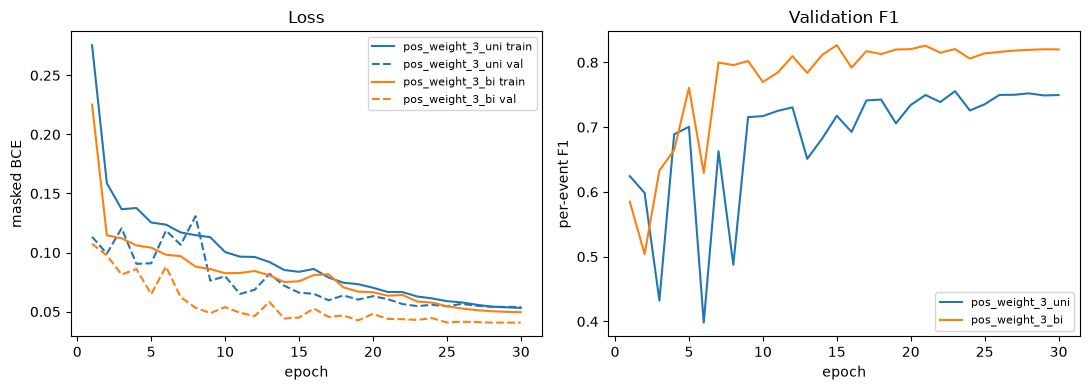

In [ ]:
# Each experiment changes one setting of BASELINE; the commented-out ones were not run
EXPERIMENTS = {
    "pos_weight_3": dict(pos_weight=3.0),                     # up-weight burnt pixels
    # "loss_bce+dice": dict(loss="bce+dice"),                 # loss closer to F1
    # "batchnorm": dict(norm="batch"),                        # GroupNorm vs BatchNorm
    # "residual": dict(block="residual"),                     # residual blocks
    # "base_32": dict(base=32),                               # less capacity
    # "adamw_wd": dict(optimizer="adamw", weight_decay=1e-4), # regularisation
    # "lr_3e-4": dict(lr=3e-4),                               # lower learning rate
    # "batch_16": dict(batch_size=16),                        # batch size
    # "constant_lr": dict(schedule="constant"),               # learning-rate schedule
}

exp_logs = {
    f"{exp}_{m}": run(f"exp_{exp}_{m}", m, 0, {**BASELINE, **changes}, RUN_EXPERIMENTS)
    for exp, changes in EXPERIMENTS.items()
    for m in MODES
}
vis.plot_training_curves(exp_logs);

In [ ]:
baseline_logs = {f"baseline_{m}": pilot_logs[f"pilot_{m}"] for m in MODES}
comparison = run_summary({**baseline_logs, **exp_logs})
comparison

,best epoch,epochs,val event F1,val precision,val recall,val pooled F1,final train loss,final val BCE,lowest val BCE at epoch,s / epoch
baseline_uni,24.0,30.0,0.760,0.820,0.790,0.832,0.033,0.028,28.0,37.033
baseline_bi,17.0,30.0,0.804,0.864,0.816,0.870,0.029,0.023,28.0,44.433
pos_weight_3_uni,23.0,30.0,0.756,0.747,0.853,0.825,0.053,0.032,27.0,36.180
pos_weight_3_bi,15.0,30.0,0.827,0.823,0.878,0.874,0.050,0.025,28.0,44.083


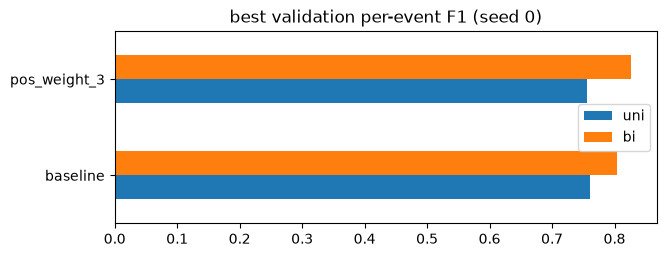

In [ ]:
# Best validation F1 per experiment, uni vs bi
names = [n.rsplit("_", 1)[0] for n in comparison.index if n.endswith("_" + MODES[0])]
best_f1 = pd.DataFrame(
    {m: [comparison.loc[f"{n}_{m}", "val event F1"] for n in names] for m in MODES},
    index=names,
)
best_f1.plot.barh(title="best validation per-event F1 (seed 0)", figsize=(7, 0.5 * len(best_f1) + 1.5));

**Decision record.** `pos_weight = 3`: recall rose and precision fell for both models, as expected (weighting burnt
pixels by w moves the loss-optimal decision to p > 1/(1 + w) = 0.25). Validation per-event F1 changed by −0.004 for M1
and +0.023 for M2: it helped only one model, by less than the 0.03 bar, and it shifts the balance towards recall when
the objective treats false alarms and misses equally. **Rejected; plain BCE kept.**

### 6.5 Final training (chosen configuration, all seeds)

In [ ]:
# Plain BCE kept: pos_weight 3 helped only bi, and by less than the 0.03 bar (6.4)
FINAL = {**BASELINE, "epochs": EPOCHS}

# FINAL equals the pilot configuration and training is deterministic (a re-run reproduced
# the pilot's logs exactly), so the pilot runs are reused as seed 0.
assert FINAL == BASELINE
for m in MODES:
    shutil.copytree(RUNS_DIR / f"pilot_{m}", RUNS_DIR / f"{m}_seed0", dirs_exist_ok=True)

logs = {
    f"{m}_seed{s}": run(f"{m}_seed{s}", m, s, FINAL, RUN_TRAINING and s != 0)
    for s in SEEDS
    for m in MODES
}

=== uni_seed1 ===


uni model: 31,041,089 parameters | 1008 train / 244 val patches | device cuda


epoch   1 | lr 1.00e-03 | train 0.1698 | val 0.0594 | event F1 0.592 (P 0.82 R 0.56) | 43s  *best*


epoch   2 | lr 9.97e-04 | train 0.0898 | val 0.0576 | event F1 0.165 (P 0.83 R 0.14) | 36s


epoch   3 | lr 9.89e-04 | train 0.0709 | val 0.0442 | event F1 0.674 (P 0.82 R 0.65) | 36s  *best*


...

epoch  26 | lr 6.70e-05 | train 0.0296 | val 0.0224 | event F1 0.800 (P 0.88 R 0.80) | 44s


epoch  27 | lr 4.32e-05 | train 0.0291 | val 0.0228 | event F1 0.783 (P 0.90 R 0.77) | 44s


epoch  28 | lr 2.45e-05 | train 0.0284 | val 0.0225 | event F1 0.785 (P 0.89 R 0.77) | 44s


epoch  29 | lr 1.09e-05 | train 0.0289 | val 0.0224 | event F1 0.792 (P 0.89 R 0.78) | 44s


epoch  30 | lr 2.74e-06 | train 0.0281 | val 0.0224 | event F1 0.793 (P 0.89 R 0.79) | 44s


### 6.6 Final training curves

,best epoch,epochs,val event F1,val precision,val recall,val pooled F1,final train loss,final val BCE,lowest val BCE at epoch,s / epoch
uni_seed0,24.0,30.0,0.760,0.820,0.790,0.832,0.033,0.028,28.0,37.033
bi_seed0,17.0,30.0,0.804,0.864,0.816,0.870,0.029,0.023,28.0,44.433
uni_seed1,24.0,30.0,0.779,0.843,0.792,0.822,0.032,0.027,30.0,36.497
bi_seed1,20.0,30.0,0.823,0.842,0.851,0.868,0.028,0.023,24.0,43.957
uni_seed2,19.0,30.0,0.752,0.769,0.835,0.810,0.032,0.031,18.0,36.677
bi_seed2,24.0,30.0,0.807,0.865,0.816,0.869,0.028,0.022,30.0,44.100


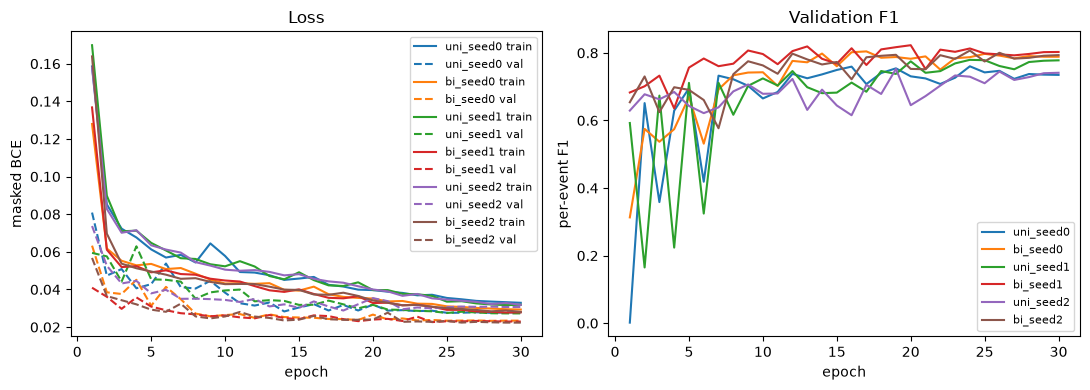

In [ ]:
vis.plot_training_curves(logs)
run_summary(logs)

## 7. Evaluation on the test fires (`src/evaluate.py`, `src/metrics.py`)
Precision, recall, F1 and IoU are computed from the pixel counts of the "burnt by this fire" class, ignoring 255.
The primary score is **per-event**: counts are summed within each fire, each fire is scored, and the scores are
averaged, so every fire counts equally however large it is. **Pooled** scores (all test pixels together, dominated by
the largest fires) are shown alongside. The threshold is fixed at 0.5, and every number is the mean ± standard
deviation over the 3 seeds.

In [ ]:
counts, group_counts, headline = {}, {}, []
for seed in SEEDS:
    for mode in MODES:
        name = f"{mode}_seed{seed}"
        model, _ = evaluate.load_model(RUNS_DIR / name / "best.pt", DEVICE)
        counts[name], group_counts[name] = evaluate.predict_counts(model, datasets["test", mode], DEVICE)
        row = metrics.summarise(counts[name]).rename(name).to_frame().T
        headline.append(row.assign(model=mode, seed=seed))

headline = pd.concat(headline)
headline.drop(columns="seed").groupby("model").agg(["mean", "std"]).round(3).T

model                     bi    uni
event_precision  mean  0.823  0.773
                 std   0.019  0.027
event_recall     mean  0.805  0.795
                 std   0.017  0.030
event_f1         mean  0.785  0.747
                 std   0.008  0.004
event_iou        mean  0.702  0.655
                 std   0.008  0.002
pooled_precision mean  0.809  0.814
                 std   0.037  0.021
pooled_recall    mean  0.933  0.910
                 std   0.005  0.013
pooled_f1        mean  0.866  0.859
                 std   0.021  0.007
pooled_iou       mean  0.764  0.753
                 std   0.032  0.010

### 7.1 Traditional baseline: thresholding a burn index (no learning)
The traditional approach thresholds a spectral burn index. dNBR = NBR(pre) − NBR(post) is the standard bi-temporal
index and −NBR(post) its post-only equivalent, so the baselines mirror the M1 / M2 comparison. Each threshold is
chosen on validation by per-event F1, the same rule used for the model checkpoints, then applied once to test. Both
U-Nets beat the best index by about 0.3 per-event F1.

In [ ]:
# Choose each index's threshold on validation, then apply it once to test
thresholds = np.round(np.arange(-0.2, 0.81, 0.02), 2)
baseline_rows = []
for kind, mode in [("nbr_post", "uni"), ("dnbr", "bi")]:
    val = evaluate.burn_index_counts(datasets["val", mode], kind, thresholds)
    val_f1 = val.groupby("threshold").apply(lambda g: metrics.summarise(g)["event_f1"])
    best = val_f1.idxmax()
    test = evaluate.burn_index_counts(datasets["test", mode], kind, [best])
    baseline_rows.append(metrics.summarise(test).rename(f"{kind} > {best:.2f}"))

pd.DataFrame(baseline_rows).round(3)

,event_precision,event_recall,event_f1,event_iou,pooled_precision,pooled_recall,pooled_f1,pooled_iou
nbr_post > 0.16,0.483,0.621,0.453,0.348,0.286,0.645,0.396,0.247
dnbr > 0.22,0.456,0.716,0.490,0.387,0.344,0.848,0.490,0.324


In [ ]:
# Test results: the U-Nets (mean over seeds) next to the burn-index baselines
cols = ["event_f1", "event_precision", "event_recall", "event_iou", "pooled_f1"]
unets = headline.groupby("model")[cols].mean().rename(index={"bi": "M2 (bi)", "uni": "M1 (uni)"})
baselines = pd.DataFrame(baseline_rows)[cols].iloc[::-1]   # dNBR first

results = pd.concat([unets.loc[["M2 (bi)", "M1 (uni)"]], baselines])
results.round(3)

,event_f1,event_precision,event_recall,event_iou,pooled_f1
M2 (bi),0.785,0.823,0.805,0.702,0.866
M1 (uni),0.747,0.773,0.795,0.655,0.859
dnbr > 0.22,0.490,0.456,0.716,0.387,0.490
nbr_post > 0.16,0.453,0.483,0.621,0.348,0.396


## 8. Analysis of results

### 8.1 M1 vs M2 per fire
Per-event F1 of every test fire, averaged over the seeds. M2 is better on 34 of the 54 test fires; points above the
diagonal are fires where M2 wins.

bi better on 34 of 54 test fires


model,bi,uni,bi - uni
fire_id,,,
505786,0.601,0.831,-0.229
804947,0.000,0.206,-0.205
586341,0.527,0.667,-0.139
774221,0.848,0.962,-0.114
543067,0.825,0.899,-0.073
783502,0.788,0.828,-0.040
867703,0.860,0.882,-0.022
592270,0.918,0.937,-0.019
878348,0.927,0.943,-0.016


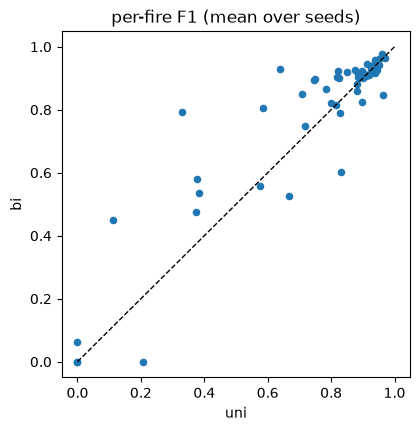

In [ ]:
# Per-event F1 of every test fire, averaged over the seeds
per_fire = pd.concat([
    metrics.event_scores(counts[f"{m}_seed{s}"]).assign(model=m)
    for s in SEEDS
    for m in MODES
])
per_fire = per_fire.groupby(["fire_id", "model"])["f1"].mean().unstack("model").dropna()
per_fire["bi - uni"] = per_fire["bi"] - per_fire["uni"]
print(f"bi better on {(per_fire['bi - uni'] > 0).sum()} of {len(per_fire)} test fires")

ax = per_fire.plot.scatter(x="uni", y="bi", title="per-fire F1 (mean over seeds)", figsize=(4.5, 4.5))
ax.plot([0, 1], [0, 1], "k--", lw=1)  # above the line: bi better on that fire
per_fire.sort_values("bi - uni").round(3)

### 8.2 Errors by land cover and on other-fire pixels (H2)
Of the pixels burnt by a *different* fire that year (FLOGA label 2, ignored in training), M1 marks about 60% as burnt
and M2 about 35%, consistently across seeds. By land cover, M2 gains most on bare/sparse land (which includes CORINE's
"burnt areas"), agriculture and artificial surfaces, the confusers named in H2, while M1 is slightly better in forest
and shrub, where a fresh burn is obvious from the post image alone. Water and wetland hold few burnt pixels.

uni_seed0: 60.6% of other-fire pixels predicted burnt
bi_seed0: 35.5% of other-fire pixels predicted burnt
uni_seed1: 60.0% of other-fire pixels predicted burnt
bi_seed1: 34.4% of other-fire pixels predicted burnt
uni_seed2: 60.6% of other-fire pixels predicted burnt
bi_seed2: 34.7% of other-fire pixels predicted burnt


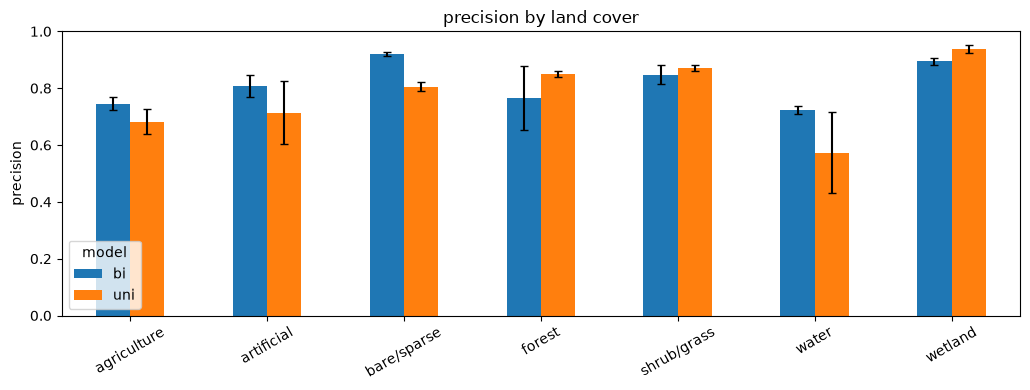

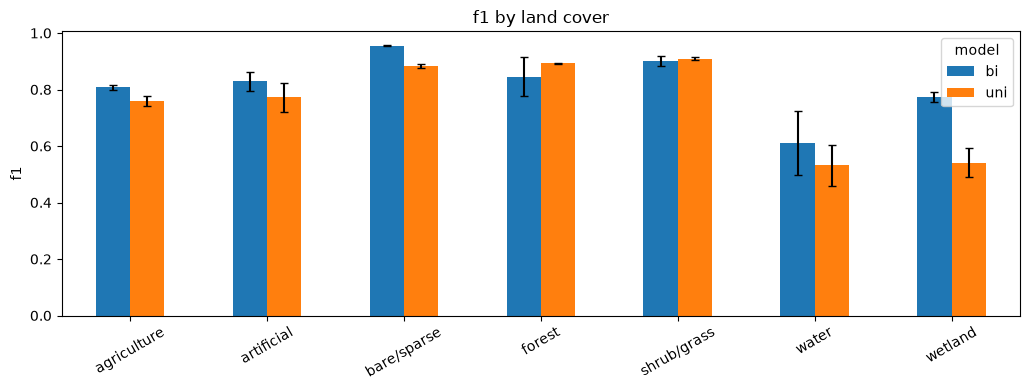

In [ ]:
# Scores per land-cover group: sum each run's counts per group, score them, then mean / std over seeds
rows = []
for name, g in group_counts.items():
    t = g.groupby("clc_group")[metrics.COUNTS].sum().drop("none", errors="ignore")
    scores = pd.DataFrame(metrics.scores(t["tp"], t["fp"], t["fn"]), index=t.index)
    rows.append(scores.assign(model=name.split("_")[0]))

by_group = pd.concat(rows).reset_index().groupby(["clc_group", "model"])
table = by_group.mean().join(by_group.std(), rsuffix="_std").reset_index()
vis.plot_by_group(table, "precision")
vis.plot_by_group(table, "f1")

# Other fires (FLOGA label 2, ignored in training and scoring): how much of them each run calls burnt
for name, c in counts.items():
    share = c["other_burnt_fp"].sum() / c["other_burnt_px"].sum()
    print(f"{name}: {share:.1%} of other-fire pixels predicted burnt")

In [ ]:
# Land-cover comparison: burnt pixels per group and mean precision / F1 over seeds, bi vs uni
burnt = group_counts["bi_seed0"].groupby("clc_group")[["tp", "fn"]].sum().sum(axis=1)
wide = table.pivot(index="clc_group", columns="model", values=["precision", "f1"])
wide.columns = [f"{metric} {model}" for metric, model in wide.columns]

land_cover = wide.assign(burnt_pixels=burnt).drop("none", errors="ignore")
land_cover = land_cover[["burnt_pixels", "precision bi", "precision uni", "f1 bi", "f1 uni"]]
land_cover.sort_values("burnt_pixels", ascending=False).round(2)

,burnt_pixels,precision bi,precision uni,f1 bi,f1 uni
clc_group,,,,,
shrub/grass,203033,0.85,0.87,0.90,0.91
agriculture,93926,0.75,0.68,0.81,0.76
forest,88106,0.77,0.85,0.85,0.89
bare/sparse,22879,0.92,0.81,0.96,0.88
wetland,13423,0.89,0.94,0.77,0.54
artificial,5002,0.81,0.71,0.83,0.77
water,518,0.72,0.57,0.61,0.53


### 8.3 Pre-image ablation
The trained M2 is re-evaluated with its pre-fire image replaced, without retraining: by the post image ("no change")
or by the pre image of a different fire. With no visible change M2 predicts almost nothing (F1 0.001), and with the
wrong reference it raises many false alarms (F1 0.324). M2 has learned change detection, not "M1 plus extra information".

In [ ]:
# Pre-image ablation: replace the bi model's pre-fire image and see how much its scores drop
rows = []
for s in SEEDS:
    model, _ = evaluate.load_model(RUNS_DIR / f"bi_seed{s}" / "best.pt", DEVICE)
    rows.append(metrics.summarise(counts[f"bi_seed{s}"]).rename("normal"))
    for how in ["post", "other_fire"]:
        ablated = evaluate.PreImageAblation(datasets["test", "bi"], how)
        c, _ = evaluate.predict_counts(model, ablated, DEVICE)
        rows.append(metrics.summarise(c).rename(f"pre = {how}"))

ablation = pd.DataFrame(rows)
ablation.groupby(level=0, sort=False).agg(["mean", "std"]).round(3).T

normal  pre = post  pre = other_fire
event_precision  mean   0.823       0.500             0.370
                 std    0.019       0.707             0.053
event_recall     mean   0.805       0.000             0.564
                 std    0.017       0.001             0.040
event_f1         mean   0.785       0.001             0.324
                 std    0.008       0.001             0.039
event_iou        mean   0.702       0.000             0.233
                 std    0.008       0.001             0.031
pooled_precision mean   0.809       0.500             0.216
                 std    0.037       0.707             0.016
pooled_recall    mean   0.933       0.000             0.799
                 std    0.005       0.001             0.031
pooled_f1        mean   0.866       0.001             0.341
                 std    0.021       0.001             0.022
pooled_iou       mean   0.764       0.000             0.205
                 std    0.032       0.001             0.016

### 8.4 Visual examples: best, middle and worst patches
Error maps for both models (orange: correct burn, red: false alarm, blue: missed burn, grey: ignored). The second cell
shows the patches where the two models differ most: M2's largest win is a burn that looks as dark as cloud shadow and
water in the post image alone; M1's largest win is a thin burn strip along a river that M2 largely misses.

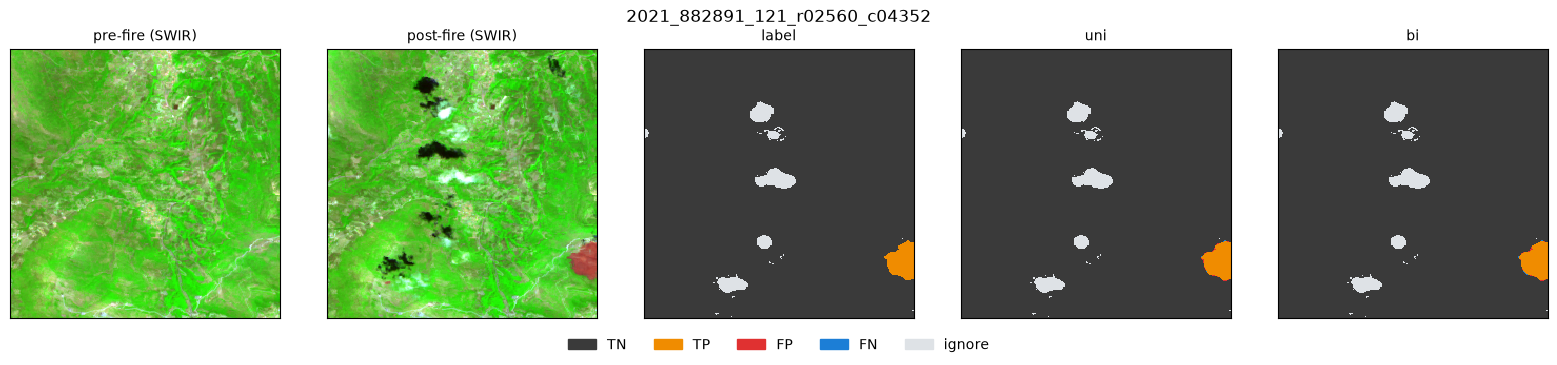

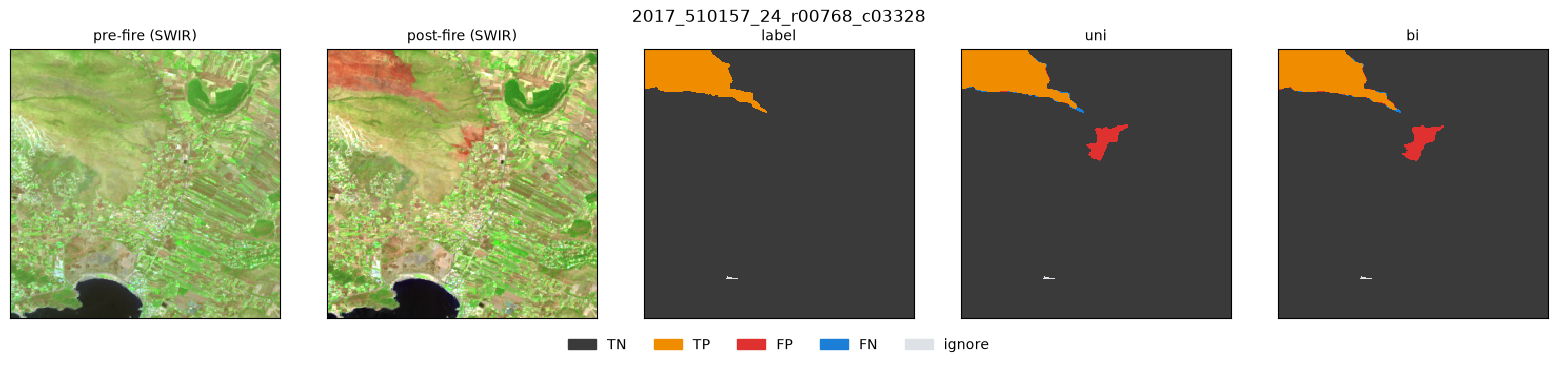

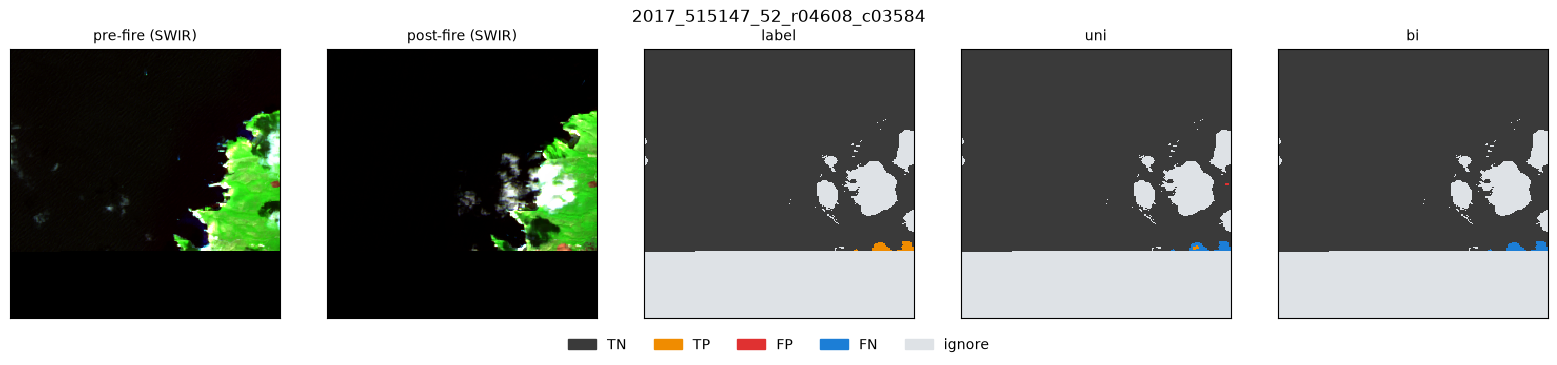

In [ ]:
# Best, middle and worst test patches (by the bi model's F1, seed 0), shown for both models
seed0 = {m: evaluate.load_model(RUNS_DIR / f"{m}_seed0" / "best.pt", DEVICE)[0] for m in MODES}
c = counts["bi_seed0"].copy()
c["f1"] = metrics.scores(c["tp"], c["fp"], c["fn"])["f1"]
c = c[c["tp"] + c["fn"] > 0].sort_values("f1")  # only patches with burnt pixels

for patch_id in c["patch_id"].iloc[[-1, len(c) // 2, 0]]:
    preds = {m: evaluate.predict_patch(seed0[m], datasets["test", m], patch_id, DEVICE) for m in MODES}
    vis.plot_prediction(preds, title=patch_id)

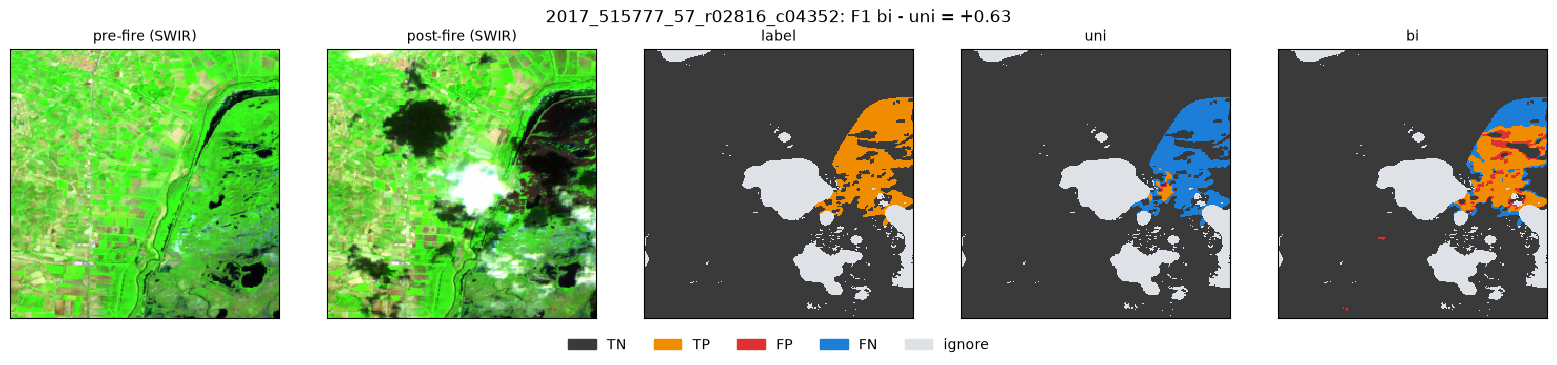

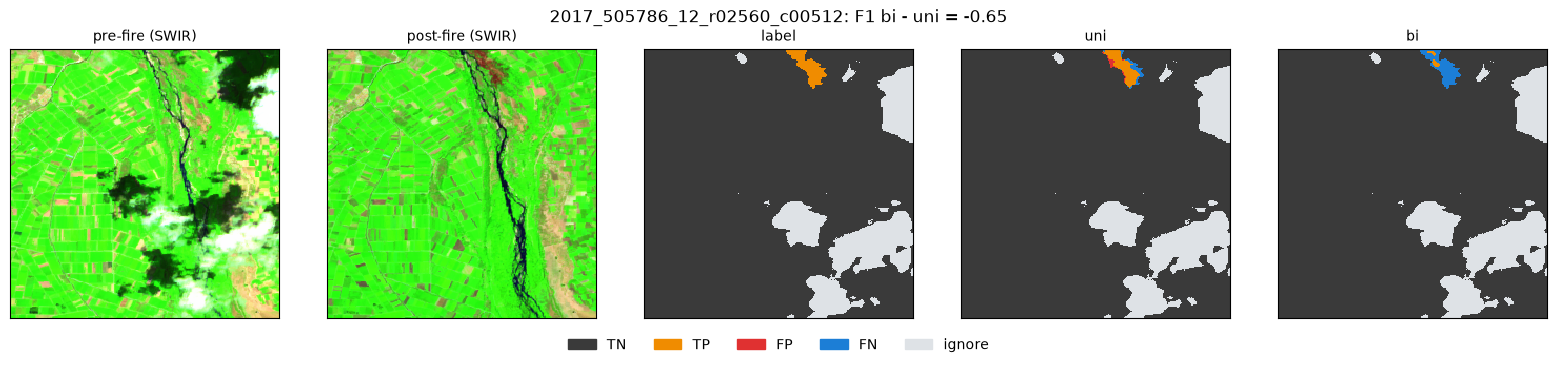

In [ ]:
# Patches where the two models differ most (seed 0): the largest win for bi, then for uni
pair = counts["bi_seed0"].merge(counts["uni_seed0"], on="patch_id", suffixes=("_bi", "_uni"))
pair = pair[pair["tp_bi"] + pair["fn_bi"] > 0].set_index("patch_id")  # only patches with burnt pixels
for m in MODES:
    pair[f"f1_{m}"] = metrics.scores(pair[f"tp_{m}"], pair[f"fp_{m}"], pair[f"fn_{m}"])["f1"]
pair["gap"] = pair["f1_bi"] - pair["f1_uni"]

for patch_id in [pair["gap"].idxmax(), pair["gap"].idxmin()]:
    preds = {m: evaluate.predict_patch(seed0[m], datasets["test", m], patch_id, DEVICE) for m in MODES}
    vis.plot_prediction(preds, title=f"{patch_id}: F1 bi - uni = {pair.loc[patch_id, 'gap']:+.2f}")

### 8.5 Whole fires

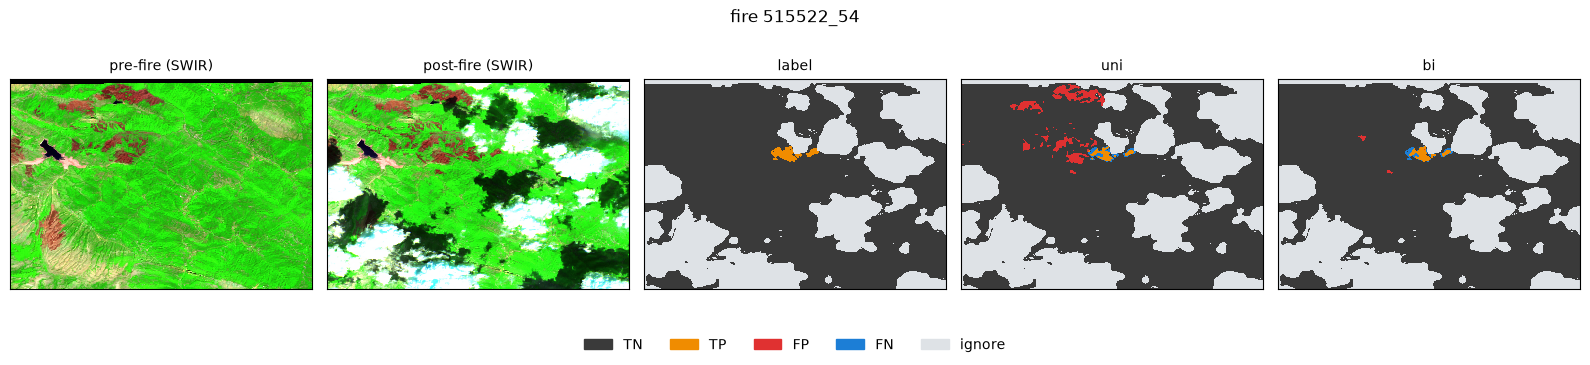

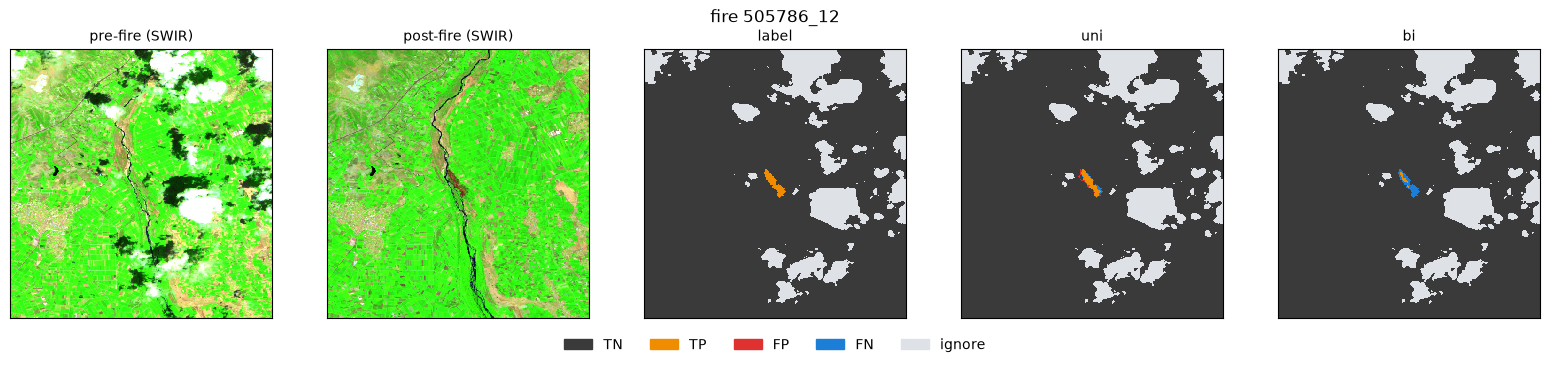

In [ ]:
# Whole fires: where bi gains most over uni and where it loses most (from 8.1), seed-0 models
tar_index = prepare_floga.index_tars(DATA_ROOT, cache=OUT_DIR / "tar_index.csv")

for fire_id in [per_fire["bi - uni"].idxmax(), per_fire["bi - uni"].idxmin()]:
    bi_counts = counts["bi_seed0"]
    raster = bi_counts.loc[bi_counts["fire_id"] == fire_id, "raster"].iloc[0]
    fire_id, n = map(int, raster.split("_"))
    preds = {
        m: evaluate.predict_fire(seed0[m], m, DATA_ROOT, tar_index, stats, fire_id, n, device=DEVICE)
        for m in MODES
    }
    vis.plot_prediction(preds, title=f"fire {raster}")

## 9. Australian zero-shot test (RQ2)
**Not completed.** Sentinel-2 imagery (9 bands) was downloaded for 11 Australian fires, but turning the official
fire-extent polygons into reliable pixel labels (agency differences, overlapping records and data-extraction issues)
did not fit in the time available. RQ2 and the Australian comparison remain future work (see the report).

In [ ]:
# Not completed: see the report's discussion (future work).

## 10. Discussion
- **RQ1: yes.** On FLOGA the pre-fire image raises per-event F1 from 0.747 ± 0.004 to 0.785 ± 0.008, about five
  times the seed spread, and M2 is better on 34 of 54 fires. Both U-Nets beat burn-index thresholding by about 0.3 F1.
- **H1 holds:** the gain is mainly precision (+0.050) rather than recall (+0.010). Pooled F1 barely moves, so the
  benefit sits in smaller fires.
- **H2 holds:** M2 marks far fewer other fires' burns as burnt (35% vs 60%) and gains most on bare land, cropland and
  artificial surfaces.
- **Loss vs objective:** training minimises pixel-level BCE while the objective is per-fire F1; checkpoint selection
  by validation per-event F1 and the threshold sweep monitored the gap.
- **Limitations:** one region (Greece); FLOGA label noise (some unlabelled burns); cloud shadow and smoke not masked;
  balanced patches rather than whole scenes; 3 seeds; M2 depends completely on a usable pre-fire image.

Full discussion, limitations and future work are in the report.